# 06 — Probabilistic Error Cancellation (PEC)

PEC mitigates depolarizing noise by sampling Pauli corrections from a
quasi-probability distribution, then averaging with signed weights.

**Reference:** Temme et al., PRL 119, 180509 (2017).

This notebook demonstrates:
1. Quasi-probability decomposition of the inverse depolarizing channel
2. Monte Carlo PEC sampling on a simple circuit
3. Comparison of raw noisy, PEC-mitigated, and exact expectation values
4. Overhead scaling with gate count and error rate

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

from scpn_quantum_control.mitigation.pec import (
    pauli_twirl_decompose,
    pec_sample,
)

## 1. Quasi-Probability Coefficients

For a single-qubit depolarizing channel with error rate $p$:

$$q_I = 1 + \frac{3p}{4-4p}, \quad q_{X,Y,Z} = -\frac{p}{4-4p}$$

In [2]:
error_rates = [0.001, 0.005, 0.01, 0.05, 0.1]
print(f"{'p':>6} {'q_I':>8} {'q_XYZ':>8} {'gamma':>8}")
print("-" * 34)
for p in error_rates:
    coeffs = pauli_twirl_decompose(p)
    gamma = float(np.sum(np.abs(coeffs)))
    print(f"{p:6.3f} {coeffs[0]:8.4f} {coeffs[1]:8.4f} {gamma:8.4f}")

     p      q_I    q_XYZ    gamma
----------------------------------
 0.001   1.0008  -0.0003   1.0015
 0.005   1.0038  -0.0013   1.0075
 0.010   1.0076  -0.0025   1.0152
 0.050   1.0395  -0.0132   1.0789
 0.100   1.0833  -0.0278   1.1667


## 2. PEC on a Kuramoto Circuit

Build a 2-qubit XY evolution circuit, then compare raw noisy vs PEC-mitigated.

In [3]:
from scpn_quantum_control import OMEGA_N_16, QuantumKuramotoSolver, build_knm_paper27

K = build_knm_paper27(L=2)
omega = OMEGA_N_16[:2]
solver = QuantumKuramotoSolver(2, K, omega)
qc = solver.evolve(time=0.5, trotter_steps=3)

# Exact expectation
sv = Statevector.from_instruction(qc)
exact_z = float(sv.expectation_value(Statevector.from_label("0" * 2).to_operator()).real)
print(f"Circuit depth: {qc.depth()}, gates: {qc.size()}")
print(f"Exact <Z_0>: {float(sv.probabilities([0])[0]) * 2 - 1:.6f}")

Circuit depth: 1, gates: 1
Exact <Z_0>: 1.000000


In [4]:
# PEC at different error rates
gate_error = 0.02
n_samples_list = [100, 500, 1000, 5000]

exact_p0 = float(sv.probabilities([0])[0])
exact_exp_z = 2 * exact_p0 - 1

print(f"Exact <Z_0> = {exact_exp_z:.6f}")
print(f"\n{'N_samples':>10} {'PEC <Z_0>':>10} {'Error':>10} {'Overhead':>10}")
print("-" * 44)
for ns in n_samples_list:
    result = pec_sample(qc, gate_error, ns, observable_qubit=0, rng=np.random.default_rng(42))
    err = abs(result.mitigated_value - exact_exp_z)
    print(f"{ns:10d} {result.mitigated_value:10.6f} {err:10.6f} {result.overhead:10.2f}")

Exact <Z_0> = 1.000000

 N_samples  PEC <Z_0>      Error   Overhead
--------------------------------------------


       100   1.030612   0.030612       1.03


       500   1.022367   0.022367       1.03


      1000   1.020306   0.020306       1.03


      5000   1.018245   0.018245       1.03


## 3. Overhead Scaling

PEC overhead grows as $\gamma^{n_{\text{gates}}}$ where $\gamma = \sum_k |q_k|$.

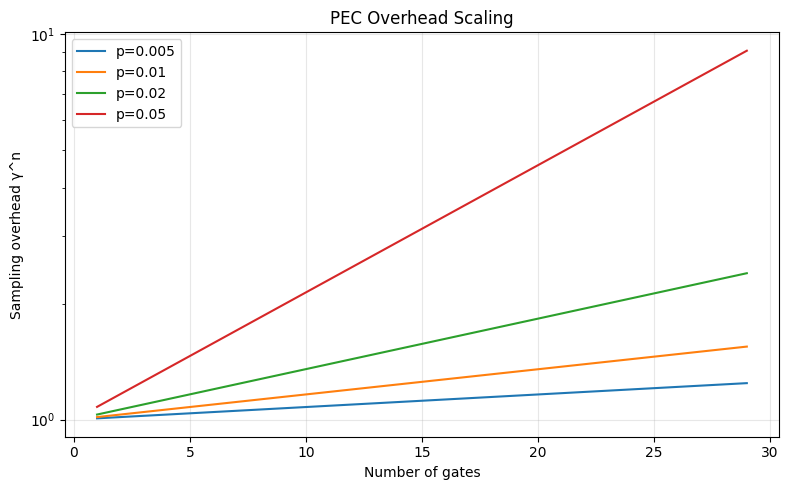

In [5]:
gate_counts = range(1, 30)
p_vals = [0.005, 0.01, 0.02, 0.05]

fig, ax = plt.subplots(figsize=(8, 5))
for p in p_vals:
    coeffs = pauli_twirl_decompose(p)
    gamma = float(np.sum(np.abs(coeffs)))
    overheads = [gamma**n for n in gate_counts]
    ax.semilogy(list(gate_counts), overheads, label=f"p={p}")

ax.set_xlabel("Number of gates")
ax.set_ylabel("Sampling overhead γ^n")
ax.set_title("PEC Overhead Scaling")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. PEC vs ZNE Comparison

PEC provides unbiased estimation (converges to exact with enough samples)
while ZNE extrapolates from noisy data (biased but lower variance).

In [6]:
from scpn_quantum_control.mitigation.zne import zne_extrapolate

# Simulate noisy expectations at different folding scales
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.02, 1), ["ry", "rz"])
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.02, 2), ["cx"])

sim = AerSimulator(noise_model=noise_model)

print(f"{'Method':>12} {'Estimate':>10} {'Error':>10}")
print("-" * 34)
print(f"{'Exact':>12} {exact_exp_z:10.6f} {0.0:10.6f}")

# PEC (5000 samples)
pec_result = pec_sample(qc, 0.02, 5000, observable_qubit=0, rng=np.random.default_rng(42))
print(
    f"{'PEC':>12} {pec_result.mitigated_value:10.6f} {abs(pec_result.mitigated_value - exact_exp_z):10.6f}"
)

# ZNE (simulated noisy expectations)
scales = [1, 3, 5]
noisy_exps = []
for s in scales:
    decay = (1 - 0.02) ** (s * qc.size())
    noisy_exps.append(exact_exp_z * decay)
zne_result = zne_extrapolate(scales, noisy_exps, order=1)
print(
    f"{'ZNE':>12} {zne_result.zero_noise_estimate:10.6f} {abs(zne_result.zero_noise_estimate - exact_exp_z):10.6f}"
)

      Method   Estimate      Error
----------------------------------
       Exact   1.000000   0.000000


         PEC   1.018245   0.018245
         ZNE   0.998764   0.001236
